In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import warnings
warnings.filterwarnings("ignore")

In [4]:
df=pd.read_csv("HR_Attrition.csv")

In [5]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [6]:
print(df.shape)

(1470, 35)


In [7]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [8]:
print(df["Attrition"].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [9]:
attrition_rate=(df["Attrition"].value_counts(normalize=True))*100
print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [10]:
numeric=df.select_dtypes(include=np.number).columns
print(len(numeric))

26


In [11]:
categorical=df.select_dtypes(include="object").columns
print(len(categorical))

9


OBSERVATION:
The dataset is imbalanced.
Around 84% employees stayed while only 16% left.
This imbalance should be handled during model training.

In [13]:
 df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [14]:
df=df.drop(columns=[
"EmployeeNumber",
"EmployeeCount",
"Over18",
"StandardHours"
])

In [15]:
df["Attrition"]=df["Attrition"].map({
"Yes":1,
"No":0
})

In [16]:
X=df.drop("Attrition",axis=1)
y=df["Attrition"]

In [17]:
cat_cols=X.select_dtypes(include="object").columns
num_cols=X.select_dtypes(exclude="object").columns

In [18]:
preprocessor=ColumnTransformer(
transformers=[
("num",StandardScaler(),num_cols),
("cat",OneHotEncoder(drop="first"),cat_cols)
]
)

In [19]:
dept=df.groupby("Department")["Attrition"].mean()*100
dept

Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition, dtype: float64

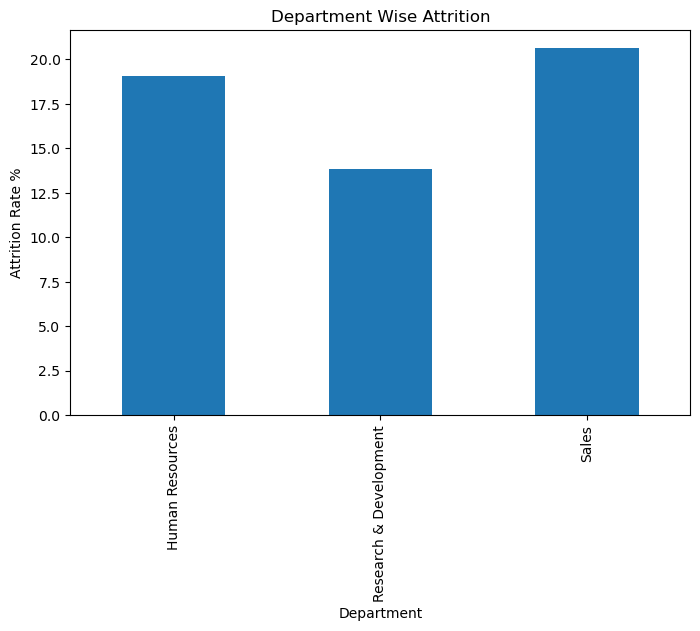

In [20]:
plt.figure(figsize=(8,5))
dept.plot(kind="bar")
plt.ylabel("Attrition Rate %")
plt.title("Department Wise Attrition")
plt.savefig("charts/department_attrition.png")
plt.show()

In [21]:
job=df.groupby("JobRole")["Attrition"].mean()*100
job.sort_values(ascending=False)

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64

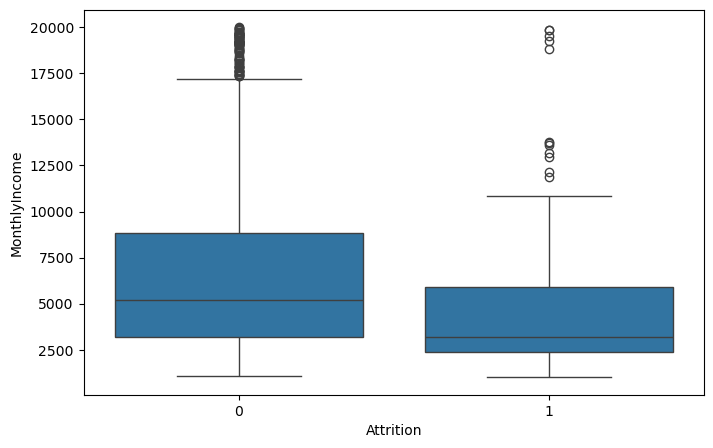

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(
data=df,
x="Attrition",
y="MonthlyIncome"
)
plt.savefig("charts/income_boxplot.png")
plt.show()

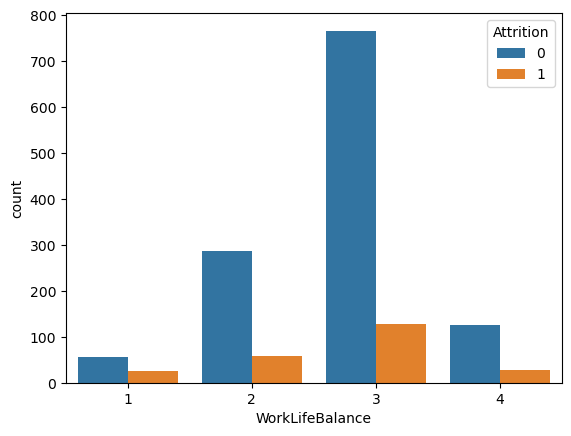

In [23]:
sns.countplot(
data=df,
x="WorkLifeBalance",
hue="Attrition"
)
plt.show()

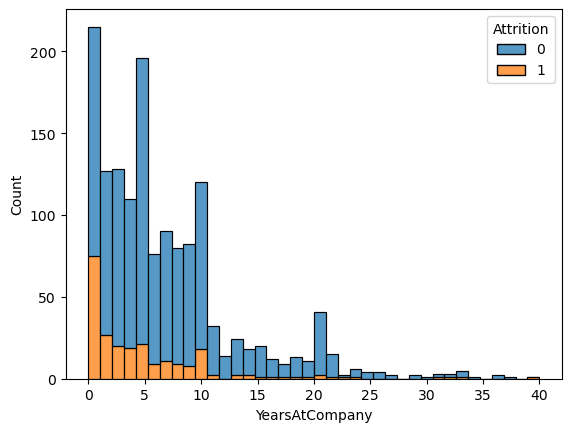

In [24]:
sns.histplot(
data=df,
x="YearsAtCompany",
hue="Attrition",
multiple="stack"
)
plt.show()

Business Insights:
Sales department shows higher attrition.
Laboratory Technicians leave more often.
Employees earning lower salaries leave more.
Employees with poor work-life balance show higher attrition.
Most employees leave within first five years.

In [25]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,random_state=42,stratify=y
)

In [26]:
lr=Pipeline([
("prep",preprocessor),
("model",LogisticRegression(
class_weight="balanced",
max_iter=1000
))
])

In [27]:
rf=Pipeline([
("prep",preprocessor),
("model",
RandomForestClassifier(
class_weight="balanced",
random_state=42

))

])

In [28]:
gb=Pipeline([
("prep",preprocessor),
("model",
GradientBoostingClassifier(
random_state=42
))

])

In [29]:
lr.fit(X_train,y_train)
rf.fit(X_train,y_train)
gb.fit(X_train,y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
models={
"Logistic":lr,
"RandomForest":rf,
"GradientBoost":gb
}

In [31]:
results=[]
for name,model in models.items():
    pred=model.predict(X_test)
    proba=model.predict_proba(X_test)[:,1]
    auc=roc_auc_score(y_test,proba)
    report=classification_report(
    y_test,
    pred,
    output_dict=True
    )
    results.append([
    name,
    report["1"]["precision"],
    report["1"]["recall"],
    report["1"]["f1-score"],
    auc
    ])

In [32]:
comparison=pd.DataFrame(
results,
columns=[
"Model","Precision","Recall","F1","ROC AUC"
])
comparison

,Model,Precision,Recall,F1,ROC AUC
0,Logistic,0.356322,0.659574,0.462687,0.803515
1,RandomForest,0.444444,0.085106,0.142857,0.754716
2,GradientBoost,0.588235,0.212766,0.312500,0.794125


In [33]:
best=rf

In [34]:
pred=best.predict(X_test)
cm=confusion_matrix(y_test,pred)

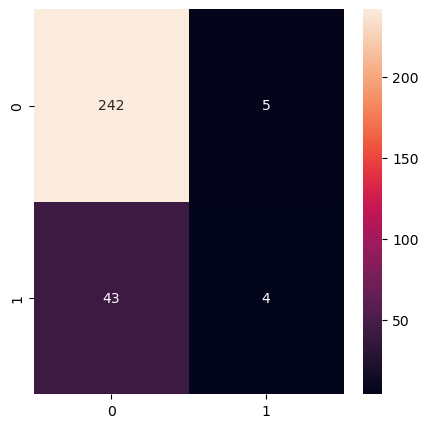

In [35]:
plt.figure(figsize=(5,5))
sns.heatmap(cm,annot=True,fmt="d")
plt.savefig("charts/confusion_matrix.png")
plt.show()

In [36]:
feature_names=best.named_steps["prep"].get_feature_names_out()
importance=best.named_steps["model"].feature_importances_
fi=pd.DataFrame({
"Feature":feature_names,"Importance":importance
})
fi=fi.sort_values("Importance",ascending=False)
fi.head(10)

,Feature,Importance
9,num__MonthlyIncome,0.075157
0,num__Age,0.068066
16,num__TotalWorkingYears,0.053865
1,num__DailyRate,0.052450
19,num__YearsAtCompany,0.048968
10,num__MonthlyRate,0.047673
5,num__HourlyRate,0.044192
2,num__DistanceFromHome,0.043070
22,num__YearsWithCurrManager,0.042613
43,cat__OverTime_Yes,0.042462


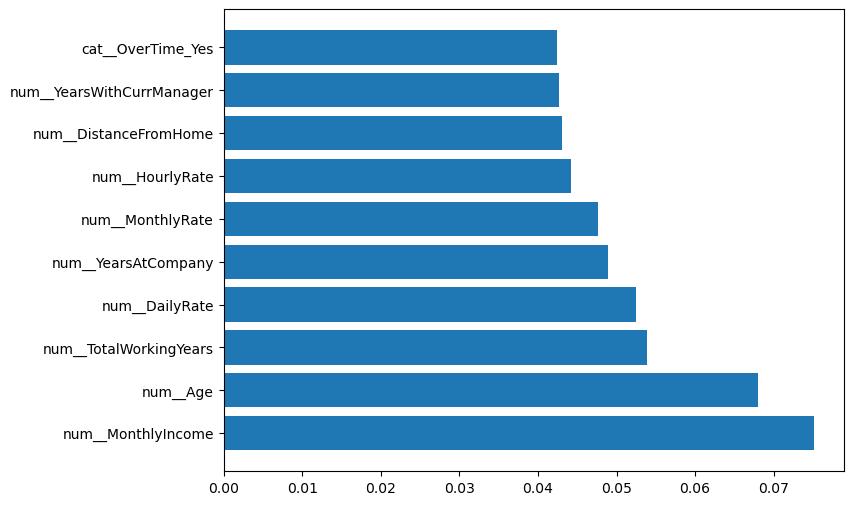

In [37]:
top=fi.head(10)
plt.figure(figsize=(8,6))
plt.barh(
top["Feature"],top["Importance"])
plt.savefig("charts/feature_importance.png")
plt.show()

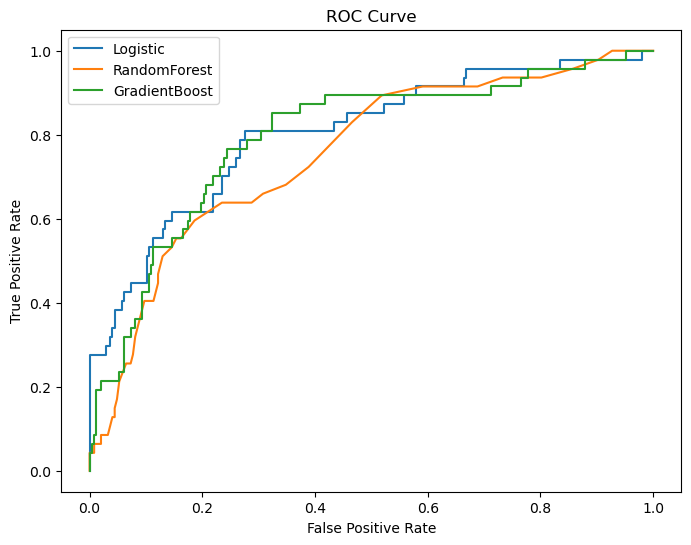

In [38]:
plt.figure(figsize=(8,6))
for name,model in models.items():
    proba=model.predict_proba(X_test)[:,1]
    fpr,tpr,_=roc_curve(y_test,proba)
    plt.plot(fpr,tpr,label=name)
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.savefig("charts/roc_curve.png")
plt.show()

HR Business Summary:

Employees with lower job satisfaction, lower monthly income, and fewer years at the company are more likely to leave.
Laboratory Technicians and Sales Representatives have the highest attrition rates and should be prioritized for retention programs.
Salary alone does not explain attrition. Work-life balance, overtime, and job satisfaction also play significant roles.
HR should conduct stay interviews for employees in high-risk roles and improve work-life balance through flexible scheduling and career development opportunities.
The model provides predictions based on historical data and should support, not replace, human HR decision-making.